# Reconocimiento de Patrones Visuales en Medicina: BloodMNIST (Hito 1)
**Autor**: [Nombre del Estudiante]  
**Curso**: Aprendizaje de Máquinas   
**Proyecto**: Sistemas avanzados para el reconocimiento de patrones visuales en medicina  
**Dataset**: **BloodMNIST** (Microscopio celular - Clasificación multiclase a color)

Este cuaderno contiene la implementación del **Hito 1 (Propuesta de proyecto e Implementación Básica)**. En esta fase, los experimentos se realizan exclusivamente con la resolución nativa de **28x28 píxeles** de BloodMNIST. Por motivos de compatibilidad de entorno con Python 3.14.3, utilizaremos **PyTorch**.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import medmnist
from medmnist import INFO, Evaluator

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)
print("MedMNIST Version:", medmnist.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

PyTorch Version: 2.12.0+cpu
Torchvision Version: 0.27.0+cpu
MedMNIST Version: 3.0.2
Using Device: cpu


## 1. Descarga y Carga del Dataset BloodMNIST (28x28)

Utilizaremos la librería oficial `medmnist` para descargar y estructurar de forma automática el dataset BloodMNIST en su división hold-out estándar (Entrenamiento, Validación y Prueba).

In [2]:
data_flag = 'bloodmnist'
download_with_medmnist = True

# Obtener información del dataset BloodMNIST
info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])
class_names = info['label']

print(f"Dataset: {info['description']}")
print(f"Task: {task}")
print(f"Channels: {n_channels} (Color RGB)")
print(f"Number of classes: {n_classes}")
print(f"Classes: {class_names}")

# Cargar clases del dataset
DataClass = getattr(medmnist, info['python_class'])

# Transformación inicial (convertir a Tensor y normalizar)
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Descargar y cargar conjuntos
train_dataset = DataClass(split='train', transform=data_transform, download=download_with_medmnist)
val_dataset = DataClass(split='val', transform=data_transform, download=download_with_medmnist)
test_dataset = DataClass(split='test', transform=data_transform, download=download_with_medmnist)

print("\n--- Tamaño de las Divisiones ---")
print(f"Entrenamiento (Train): {len(train_dataset)} imágenes")
print(f"Validación (Val): {len(val_dataset)} imágenes")
print(f"Prueba (Test): {len(test_dataset)} imágenes")

Dataset: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
Task: multi-class
Channels: 3 (Color RGB)
Number of classes: 8
Classes: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}



--- Tamaño de las Divisiones ---
Entrenamiento (Train): 11959 imágenes
Validación (Val): 1712 imágenes
Prueba (Test): 3421 imágenes


## 2. Análisis Exploratorio de Datos (EDA)

Realizaremos un análisis visual y estadístico del conjunto de datos para comprender el balance de clases, las muestras celulares típicas y las características de los canales a color.

,Clase ID,Clase Nombre (EN),Clase Nombre (ES),Entrenamiento (Train),Porcentaje (%)
0,0,basophil,Basófilo (basophil),852,7.12
1,1,eosinophil,Eosinófilo (eosinophil),2181,18.24
2,2,erythroblast,Eritroblasto (erythroblast),1085,9.07
3,3,"immature granulocytes(myelocytes, metamyelocyt...",Granulocito inmaduro (ig),2026,16.94
4,4,lymphocyte,Linfocito (lymphocyte),849,7.10
5,5,monocyte,Monocito (monocyte),993,8.30
6,6,neutrophil,Neutrófilo (neutrophil),2330,19.48
7,7,platelet,Plaqueta (platelet),1643,13.74


C:\Users\msantos\AppData\Local\Temp\ipykernel_26512\3656939668.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Clase Nombre (ES)', y='Entrenamiento (Train)', data=class_distribution, palette='viridis')


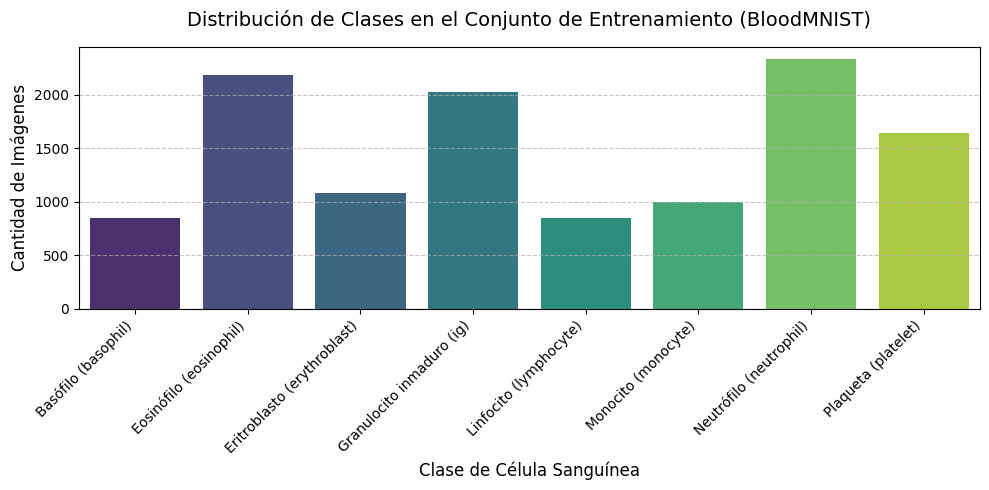

In [3]:
# Mapeo de índices de clases a nombres médicos en español e inglés
class_mapping_es = {
    '0': 'Basófilo (basophil)',
    '1': 'Eosinófilo (eosinophil)',
    '2': 'Eritroblasto (erythroblast)',
    '3': 'Granulocito inmaduro (ig)',
    '4': 'Linfocito (lymphocyte)',
    '5': 'Monocito (monocyte)',
    '6': 'Neutrófilo (neutrophil)',
    '7': 'Plaqueta (platelet)'
}

# Obtener etiquetas de entrenamiento
train_labels = train_dataset.labels.squeeze()
val_labels = val_dataset.labels.squeeze()
test_labels = test_dataset.labels.squeeze()

# Calcular frecuencias
unique, counts = np.unique(train_labels, return_counts=True)
class_distribution = pd.DataFrame({
    'Clase ID': unique,
    'Clase Nombre (EN)': [class_names[str(u)] for u in unique],
    'Clase Nombre (ES)': [class_mapping_es[str(u)] for u in unique],
    'Entrenamiento (Train)': counts,
    'Porcentaje (%)': np.round(counts / len(train_labels) * 100, 2)
})

# Mostrar tabla de distribución
display(class_distribution)

# Graficar balance de clases
plt.figure(figsize=(10, 5))
sns.barplot(x='Clase Nombre (ES)', y='Entrenamiento (Train)', data=class_distribution, palette='viridis')
plt.title('Distribución de Clases en el Conjunto de Entrenamiento (BloodMNIST)', fontsize=14, pad=15)
plt.xlabel('Clase de Célula Sanguínea', fontsize=12)
plt.ylabel('Cantidad de Imágenes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualización de Muestras de Células
Mostraremos una muestra visual representativa de cada una de las 8 clases de células sanguíneas para observar la calidad, morfología y el color a resolución 28x28 píxeles.

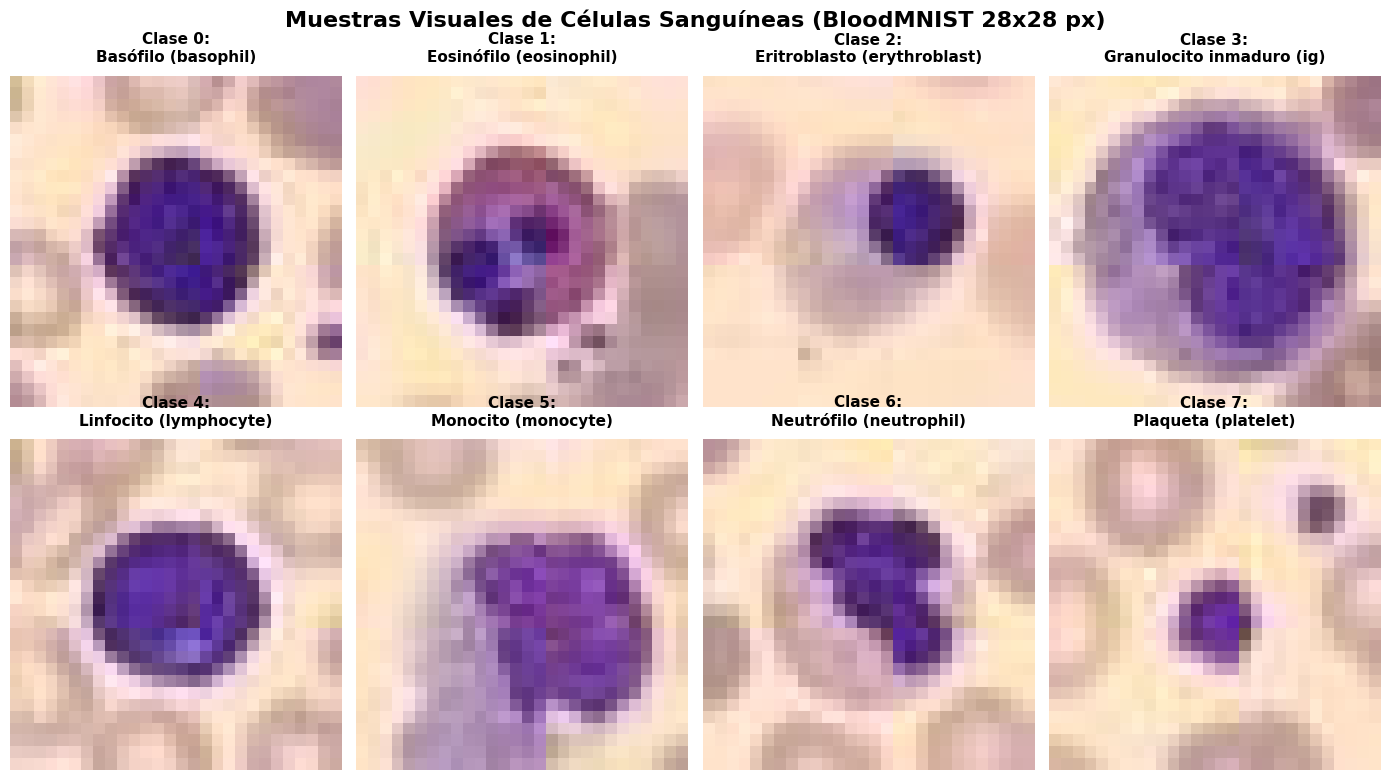

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

# Cargar el dataset sin normalizar para visualización directa
visual_dataset = DataClass(split='train', download=False)

# Buscar una muestra representativa de cada clase
for class_id in range(8):
    idx = np.where(train_labels == class_id)[0][0]
    img, label = visual_dataset[idx]
    
    ax = axes[class_id]
    ax.imshow(img)
    ax.set_title(f"Clase {class_id}:\n{class_mapping_es[str(class_id)]}", fontsize=11, fontweight='bold', pad=10)
    ax.axis('off')

plt.suptitle('Muestras Visuales de Células Sanguíneas (BloodMNIST 28x28 px)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 3. Pipeline de Datos y Data Augmentation

Definiremos transformaciones avanzadas para robustecer el entrenamiento y evitar el sobreajuste. De acuerdo con las pautas del Hito 1, trabajaremos exclusivamente con la resolución nativa de **28x28 píxeles** de BloodMNIST. Esto garantiza el cumplimiento estricto de las restricciones del avance, permitiendo evaluar el rendimiento del baseline bajo la escala espacial original.

In [5]:
BATCH_SIZE = 64
IMAGE_SIZE = 28  # Resolución nativa obligatoria para Hito 1

# Transformación de Entrenamiento (con Data Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Transformación de Validación y Prueba (sin Data Augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Aplicar las transformaciones
train_dataset.transform = train_transform
val_dataset.transform = eval_transform
test_dataset.transform = eval_transform

# Crear DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Dataloaders creados exitosamente.")
print(f"Lotes de entrenamiento: {len(train_loader)} (Batch size: {BATCH_SIZE})")
print(f"Lotes de validación: {len(val_loader)}")
print(f"Lotes de prueba: {len(test_loader)}")

Dataloaders creados exitosamente.
Lotes de entrenamiento: 187 (Batch size: 64)
Lotes de validación: 27
Lotes de prueba: 54


## 4. Modelo CNN Baseline (Fine-tuning de ResNet-18 con Adaptación Espacial)

Cargaremos el modelo **ResNet-18** con pesos pre-entrenados de ImageNet de la librería `torchvision.models`.

**Estrategia de Adaptación Espacial para 28x28**:
Para evitar que las imágenes de baja resolución ($28\times28$ px) se colapsen espacialmente de forma prematura a $1\times1$ en las primeras capas debido al stride 2 y al maxpool de la arquitectura original, aplicaremos dos modificaciones ad-hoc:
1. **Rediseño de `conv1`**: Reemplazaremos la primera convolución de 7x7 (stride 2) por una convolución de 3x3 con stride 1 y padding 1, manteniendo la resolución espacial inicial.
2. **Eliminación de `maxpool`**: Reemplazaremos la capa `maxpool` original por una Identidad (`nn.Identity()`).

Esto preservará los detalles visuales de la morfología celular para que lleguen intactos a los bloques profundos. Habilitaremos los gradientes para esta nueva `conv1` y para el clasificador final `fc` durante la fase inicial de extracción de características.

In [6]:
# Cargar ResNet-18 pre-entrenada
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modificar la primera capa convolucional para imágenes de 28x28 (se inicializa aleatoriamente y debe ser entrenable)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

# Eliminar la capa maxpool (reemplazar por nn.Identity) para preservar la resolución espacial
model.maxpool = nn.Identity()

# Congelar todos los parámetros del modelo base
for param in model.parameters():
    param.requires_grad = False

# Habilitar gradientes para la nueva primera capa convolucional
for param in model.conv1.parameters():
    param.requires_grad = True

# Adaptar el clasificador final
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, n_classes)
)

model = model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(

### Definición de Función de Pérdida y Optimizador

Usaremos CrossEntropyLoss (entropía cruzada) y el optimizador Adam. Primero entrenaremos únicamente la cabeza de clasificación (`model.fc`).

In [7]:
criterion = nn.CrossEntropyLoss()
# Optimizar solo los parámetros que requieren gradiente (cabeza clasificadora)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)

print("Optimizador configurado para entrenamiento inicial.")

Optimizador configurado para entrenamiento inicial.


## 5. Entrenamiento del Clasificador (Fase de Extracción de Características)

Definiremos una función para entrenar y evaluar el modelo en cada época.

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device).squeeze().long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)
        total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = (correct.double() / total).item()
    return epoch_loss, epoch_acc

def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device).squeeze().long()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
            
    epoch_loss = running_loss / total
    epoch_acc = (correct.double() / total).item()
    return epoch_loss, epoch_acc

In [9]:
EPOCHS_EXTRACT = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Iniciando fase de Extracción de Características (capas base congeladas)...")
for epoch in range(EPOCHS_EXTRACT):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Época {epoch+1}/{EPOCHS_EXTRACT} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Iniciando fase de Extracción de Características (capas base congeladas)...


Época 1/5 - Train Loss: 0.9407, Train Acc: 0.6638 | Val Loss: 0.6159, Val Acc: 0.7786


Época 2/5 - Train Loss: 0.6409, Train Acc: 0.7655 | Val Loss: 0.5615, Val Acc: 0.7874


Época 3/5 - Train Loss: 0.5714, Train Acc: 0.7891 | Val Loss: 0.4782, Val Acc: 0.8172


Época 4/5 - Train Loss: 0.5282, Train Acc: 0.8132 | Val Loss: 0.4160, Val Acc: 0.8470


Época 5/5 - Train Loss: 0.5079, Train Acc: 0.8131 | Val Loss: 0.4016, Val Acc: 0.8511


## 6. Fine-Tuning del Modelo

Ahora descongelaremos los últimos bloques convolucionales de la red ResNet-18 (específicamente la capa `layer4`, `conv1` y la cabeza `fc`) para realizar un ajuste fino con una tasa de aprendizaje significativamente menor (`1e-5`). Esto permitirá afinar la extracción de características y adaptar las capas superiores conjuntamente con la entrada a las células microscópicas a baja resolución.

In [10]:
# Descongelar las capas del último bloque convolucional (layer4), conv1 y del clasificador (fc)
for name, child in model.named_children():
    if name in ['layer4', 'fc', 'conv1']:
        print(f"Descongelando capa: {name}")
        for param in child.parameters():
            param.requires_grad = True
    else:
        for param in child.parameters():
            param.requires_grad = False

# Configurar el optimizador con una tasa de aprendizaje mucho más pequeña para el ajuste fino
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=1e-4)

Descongelando capa: conv1
Descongelando capa: layer4
Descongelando capa: fc


In [11]:
EPOCHS_FT = 7

print("\nIniciando fase de Ajuste Fino (Fine-Tuning)...")
for epoch in range(EPOCHS_FT):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer_ft, device)
    val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Época {epoch+1+EPOCHS_EXTRACT}/{EPOCHS_EXTRACT+EPOCHS_FT} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Iniciando fase de Ajuste Fino (Fine-Tuning)...


Época 6/12 - Train Loss: 0.4335, Train Acc: 0.8384 | Val Loss: 0.3267, Val Acc: 0.8750


Época 7/12 - Train Loss: 0.3924, Train Acc: 0.8570 | Val Loss: 0.2935, Val Acc: 0.8914


Época 8/12 - Train Loss: 0.3584, Train Acc: 0.8696 | Val Loss: 0.2760, Val Acc: 0.8966


Época 9/12 - Train Loss: 0.3456, Train Acc: 0.8730 | Val Loss: 0.2635, Val Acc: 0.9083


Época 10/12 - Train Loss: 0.3228, Train Acc: 0.8796 | Val Loss: 0.2484, Val Acc: 0.9136


Época 11/12 - Train Loss: 0.3134, Train Acc: 0.8844 | Val Loss: 0.2386, Val Acc: 0.9206


Época 12/12 - Train Loss: 0.2996, Train Acc: 0.8892 | Val Loss: 0.2287, Val Acc: 0.9223


## 7. Reporte Gráfico de Resultados y Métricas de Evaluación

Graficaremos las curvas de pérdida y exactitud del modelo a lo largo de todo el entrenamiento.

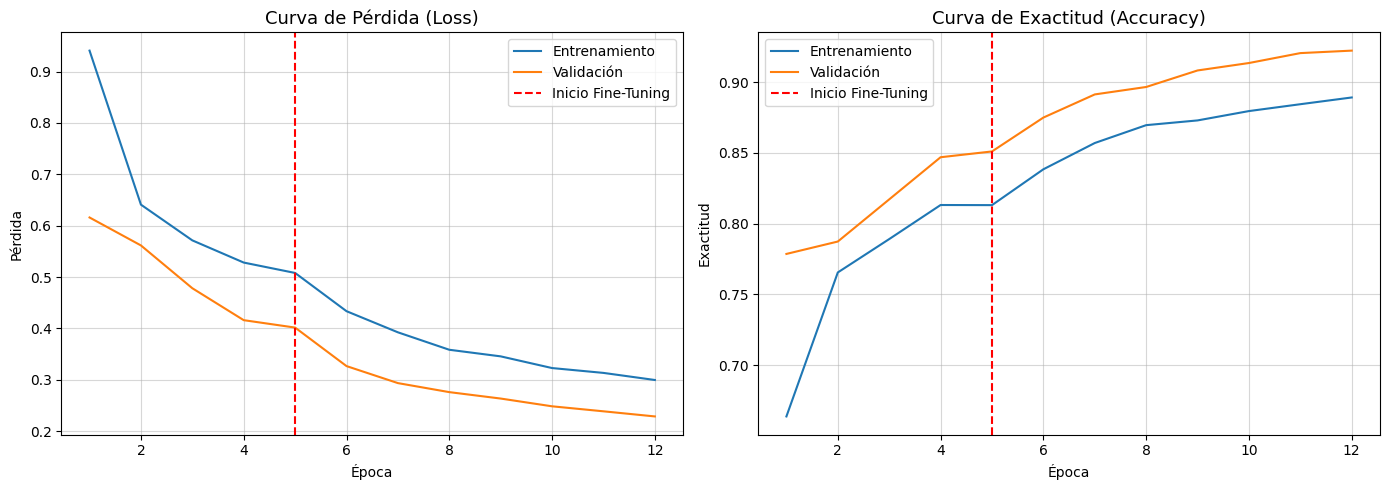

In [12]:
# Graficar pérdidas e historiales de exactitud
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Entrenamiento')
plt.plot(epochs_range, history['val_loss'], label='Validación')
plt.axvline(x=EPOCHS_EXTRACT, color='r', linestyle='--', label='Inicio Fine-Tuning')
plt.title('Curva de Pérdida (Loss)', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.5)

# Exactitud
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Entrenamiento')
plt.plot(epochs_range, history['val_acc'], label='Validación')
plt.axvline(x=EPOCHS_EXTRACT, color='r', linestyle='--', label='Inicio Fine-Tuning')
plt.title('Curva de Exactitud (Accuracy)', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

### Evaluación sobre el Conjunto de Prueba (Test)

Calcularemos las métricas globales exigidas (Accuracy, F1-Score ponderado y AUC-ROC) y generaremos la matriz de confusión detallada.

In [13]:
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).squeeze().long()
        
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calcular métricas principales
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='weighted')
test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

print("\n=== MÉTRICAS EN EL CONJUNTO DE PRUEBA (TEST) ===")
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"AUC-ROC:   {test_auc:.4f} ({test_auc*100:.2f}%)")


=== MÉTRICAS EN EL CONJUNTO DE PRUEBA (TEST) ===
Accuracy:  0.9138 (91.38%)
F1-Score:  0.9140 (91.40%)
AUC-ROC:   0.9921 (99.21%)



--- Reporte de Clasificación por Clase ---
                                                                     precision    recall  f1-score   support

                                                           basophil       0.82      0.82      0.82       244
                                                         eosinophil       0.98      0.98      0.98       624
                                                       erythroblast       0.95      0.90      0.92       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.78      0.85      0.82       579
                                                         lymphocyte       0.93      0.88      0.90       243
                                                           monocyte       0.87      0.77      0.81       284
                                                         neutrophil       0.95      0.96      0.96       666
                                                           platelet       1.00     

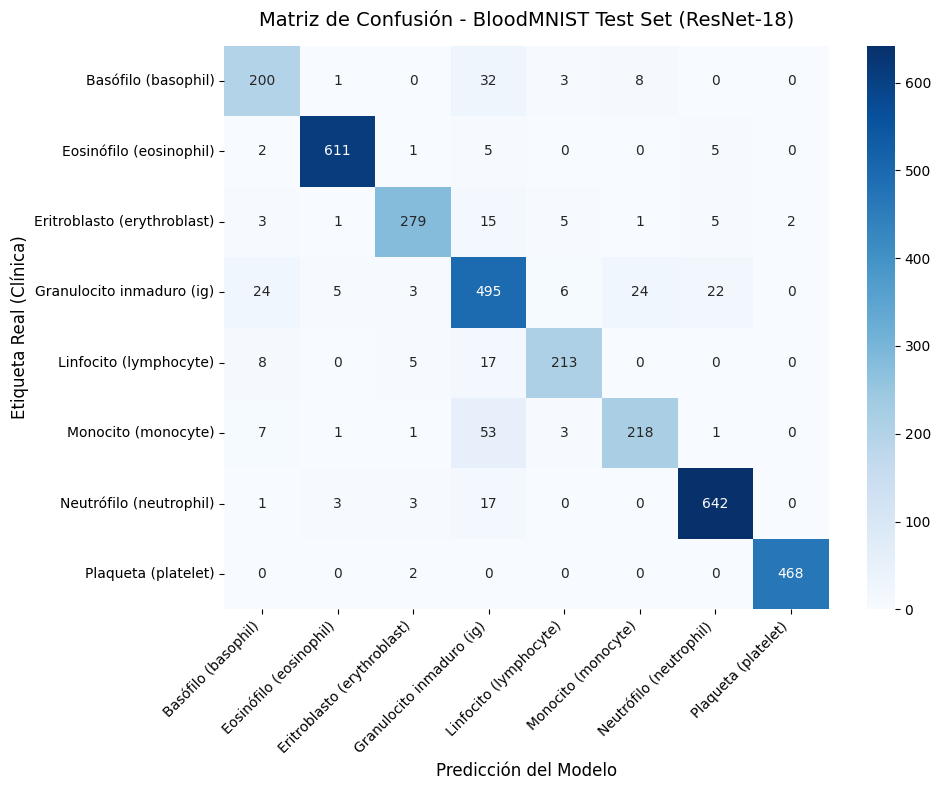

In [14]:
# 1. Reporte de Clasificación Detallado
print("\n--- Reporte de Clasificación por Clase ---")
print(classification_report(all_labels, all_preds, target_names=[class_names[str(i)] for i in range(8)]))

# 2. Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_mapping_es[str(i)] for i in range(8)],
            yticklabels=[class_mapping_es[str(i)] for i in range(8)])
plt.title('Matriz de Confusión - BloodMNIST Test Set (ResNet-18)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Etiqueta Real (Clínica)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()